# Real Data Resolution Sensitivity — Matérn ν=1 (smooth=1.0) via Cubic Spline

**Goal**: Fit `HybridVecchiaS10Lean` on real GEMS TCO data at 4 observation
densities (R=8 coarsest → R=1 finest, via maxmin-order thinning).  
Track how parameter estimates change as data volume increases.

**Model**: Matérn ν=1 (smooth=1.0) approximated by natural cubic spline of  
f(r) = √2·r·K₁(√2·r), so that autograd flows through the spline for L-BFGS.

**Lean conditioning** (Hybrid_Lean_L08F04_C4F03, fixed offset 0.063):
- Set A (t): 20 spatial NN
- Set B (t-1): anchor + 8 local + 4 fresh upstream-shifted
- Set C (t-2): anchor + 4 local + 3 fresh 2×upstream-shifted

| Resolution | R=8 | R=4 | R=2 | R=1 |
|---|---|---|---|---|
| smooth=1.0 | ✓ | ✓ | ✓ | ✓ |

In [1]:
import sys, time, gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

sys.path.insert(0, "/Users/joonwonlee/Documents/GEMS_TCO-1/src")
from GEMS_TCO import configuration as config
from GEMS_TCO import orderings as _orderings
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO.vecchia_s10_hybrid_lean import HybridVecchiaS10Lean

print('torch:', torch.__version__)
print('device: cpu (Mac)')

torch: 2.5.1
device: cpu (Mac)


In [2]:
# ── experiment config ──────────────────────────────────────────────────
DEVICE = torch.device('cpu')
DTYPE  = torch.float64

YEAR         = '2023'
MONTH        = 7
DAY_IDX_LIST = [7, 8, 9]   # 0-based → July 8, 9, 10 2023
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]

# ── Lean Vecchia hyperparams (Hybrid_Lean_L08F04_C4F03) ───────────────
MM_COND_NUMBER  = 100
NHEADS          = 100
LIMIT_A         = 20
LIMIT_B_LOCAL   = 8    # Lean: local 8 at lag-1   (vs 16 in original)
LIMIT_C_LOCAL   = 4    # Lean: local 4 at lag-2   (vs 12 in original)
DAILY_STRIDE    = 2
LAG1_FRESH      = 4    # Lean: fresh 4 at lag-1   (vs 2 in original)
LAG2_FRESH      = 3    # Lean: fresh 3 at lag-2   (vs 2 in original)
LAG1_LON_OFFSET = 0.063

# ── optimizer ─────────────────────────────────────────────────────────
LBFGS_LR    = 1.0
LBFGS_STEPS = 10
LBFGS_EVAL  = 20
LBFGS_HIST  = 10

# ── resolution axis ───────────────────────────────────────────────────
RESOLUTION_MULTS = [8, 4, 2, 1]   # thinning; 8=coarsest, 1=finest

# ── initial values (physical scale) ──────────────────────────────────
INIT_DICT = {
    'sigmasq':    13.059,
    'range_lat':  0.2,
    'range_lon':  0.25,
    'range_time': 1.5,
    'advec_lat':  0.0218,
    'advec_lon':  -0.1689,
    'nugget':     0.247,
}

P_LABELS = ['sigmasq', 'range_lat', 'range_lon', 'range_time',
            'advec_lat', 'advec_lon', 'nugget']
P_DISP   = [r'$\sigma^2$ (sigmasq)', 'range_lat', 'range_lon', 'range_time',
            r'$\alpha_{lat}$', r'$\alpha_{lon}$', 'nugget']

print(f'Config loaded.  DAY_IDX_LIST={DAY_IDX_LIST}')

Config loaded.  DAY_IDX_LIST=[7, 8, 9]


In [3]:
# ── parameter reparametrization (same as original notebook) ───────────
def phys_to_log(d):
    """Physical params → log-reparametrized [logφ1,logφ2,logφ3,logφ4,advec_lat,advec_lon,log_nugget]."""
    phi2 = 1.0 / d['range_lon']
    phi1 = d['sigmasq'] * phi2
    phi3 = (d['range_lon'] / d['range_lat']) ** 2
    phi4 = (d['range_lon'] / d['range_time']) ** 2
    return [np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4),
            d['advec_lat'], d['advec_lon'], np.log(d['nugget'])]


def backmap_params(out_params):
    """Log-reparametrized → physical."""
    p    = [float(x.item() if isinstance(x, torch.Tensor) else x) for x in out_params[:7]]
    phi2 = np.exp(p[1])
    phi3 = np.exp(p[2])
    phi4 = np.exp(p[3])
    rlon = 1.0 / phi2
    return {
        'sigmasq':    np.exp(p[0]) / phi2,
        'range_lat':  rlon / phi3 ** 0.5,
        'range_lon':  rlon,
        'range_time': rlon / phi4 ** 0.5,
        'advec_lat':  p[4],
        'advec_lon':  p[5],
        'nugget':     np.exp(p[6]),
    }


INIT_LOG = phys_to_log(INIT_DICT)
print('Initial log-params:', [f'{v:.4f}' for v in INIT_LOG])

Initial log-params: ['3.9558', '1.3863', '0.4463', '-3.5835', '0.0218', '-0.1689', '-1.3984']


In [4]:
# ── load full month data (done once) ──────────────────────────────────
loader = load_data_dynamic_processed(config.mac_data_load_path)

df_map, ord_mm, nns_map_full, monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=MM_COND_NUMBER,
    years_=[YEAR],
    months_=[MONTH],
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=False,
)

sorted_df_keys = sorted(df_map.keys())
print(f'Monthly mean TCO: {monthly_mean:.4f}')
print(f'Total time slots in month: {len(sorted_df_keys)}')

--- Global Monthly Mean for 2023-7: 249.7131 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
Monthly mean TCO: 249.7131
Total time slots in month: 248


In [5]:
# ── extract grid coordinates (fixed across all days) ──────────────────
first_df = df_map[sorted_df_keys[0]].iloc[ord_mm].reset_index(drop=True)
grid_coords_ordered = first_df[['Latitude', 'Longitude']].values.astype(np.float64)
n_grid_full = len(grid_coords_ordered)

print(f'Grid: {n_grid_full:,} cells')
print(f'lat range: {grid_coords_ordered[:,0].min():.2f} – {grid_coords_ordered[:,0].max():.2f}')
print(f'lon range: {grid_coords_ordered[:,1].min():.2f} – {grid_coords_ordered[:,1].max():.2f}')

Grid: 18,126 cells
lat range: -2.97 – 2.00
lon range: 121.05 – 131.00


In [6]:
# ── precompute NNS per resolution (same for all days) ─────────────────
nns_setups = {}

for R in RESOLUTION_MULTS:
    n_thin              = round(n_grid_full / R)
    thin_idx            = np.arange(0, n_thin)
    thin_spatial_coords = grid_coords_ordered[thin_idx]        # (lat, lon)
    thin_coords_lonlat  = thin_spatial_coords[:, ::-1].copy()  # (lon, lat) for find_nns_l2

    nns_thin = _orderings.find_nns_l2(locs=thin_coords_lonlat, max_nn=MM_COND_NUMBER)

    nns_setups[R] = {
        'thin_idx':       thin_idx,
        'nns':            nns_thin,
        'spatial_coords': thin_spatial_coords,
        'n_grid':         n_thin,
    }
    print(f'R={R:2d}: n_grid={n_thin:6,}  nns_shape={nns_thin.shape}')

print('NNS precompute done.')

R= 8: n_grid= 2,266  nns_shape=(2266, 100)
R= 4: n_grid= 4,532  nns_shape=(4532, 100)
R= 2: n_grid= 9,063  nns_shape=(9063, 100)
R= 1: n_grid=18,126  nns_shape=(18126, 100)
NNS precompute done.



DAY 20230708:  2023_07_y23m07day08_hm00:53  …  2023_07_y23m07day08_hm07:48
  R= 8: n_grid= 2,266  valid_obs=  17,871
  R= 4: n_grid= 4,532  valid_obs=  35,780
  R= 2: n_grid= 9,063  valid_obs=  71,640
  R= 1: n_grid=18,126  valid_obs= 143,238

  Fitting: smooth=1.0  R=8  [n_obs=17,871]
[HybridVecchiaS10Lean] Matérn ν=1 spline built: 500 knots, r_max=15.0, f(0)=1.0000, f(1)=0.4443, device=cpu
Pre-computing HybridVecchia (smooth=1.0) [A=20, AB=33, ABC=41, B=local8+fresh4, C=local4+fresh3, lag1_offset=0.0630, stored=1]... [Mean Lat: -0.5060] [SetC=True] Done. (Heads=774, Tails A/AB/ABC=2142/2141/12814)
--- Starting Batched L-BFGS Optimization (GPU) ---
--- Step 1/10 / Loss: 1.653511 ---
  Param 0: Value=3.7335, Grad=0.059407822199625114
  Param 1: Value=1.1509, Grad=0.005645401156552068
  Param 2: Value=1.5200, Grad=0.019084029398365503
  Param 3: Value=-2.3961, Grad=0.008578225542642127
  Param 4: Value=0.0017, Grad=0.012319702992082071
  Param 5: Value=-0.1550, Grad=-0.0295022654996364

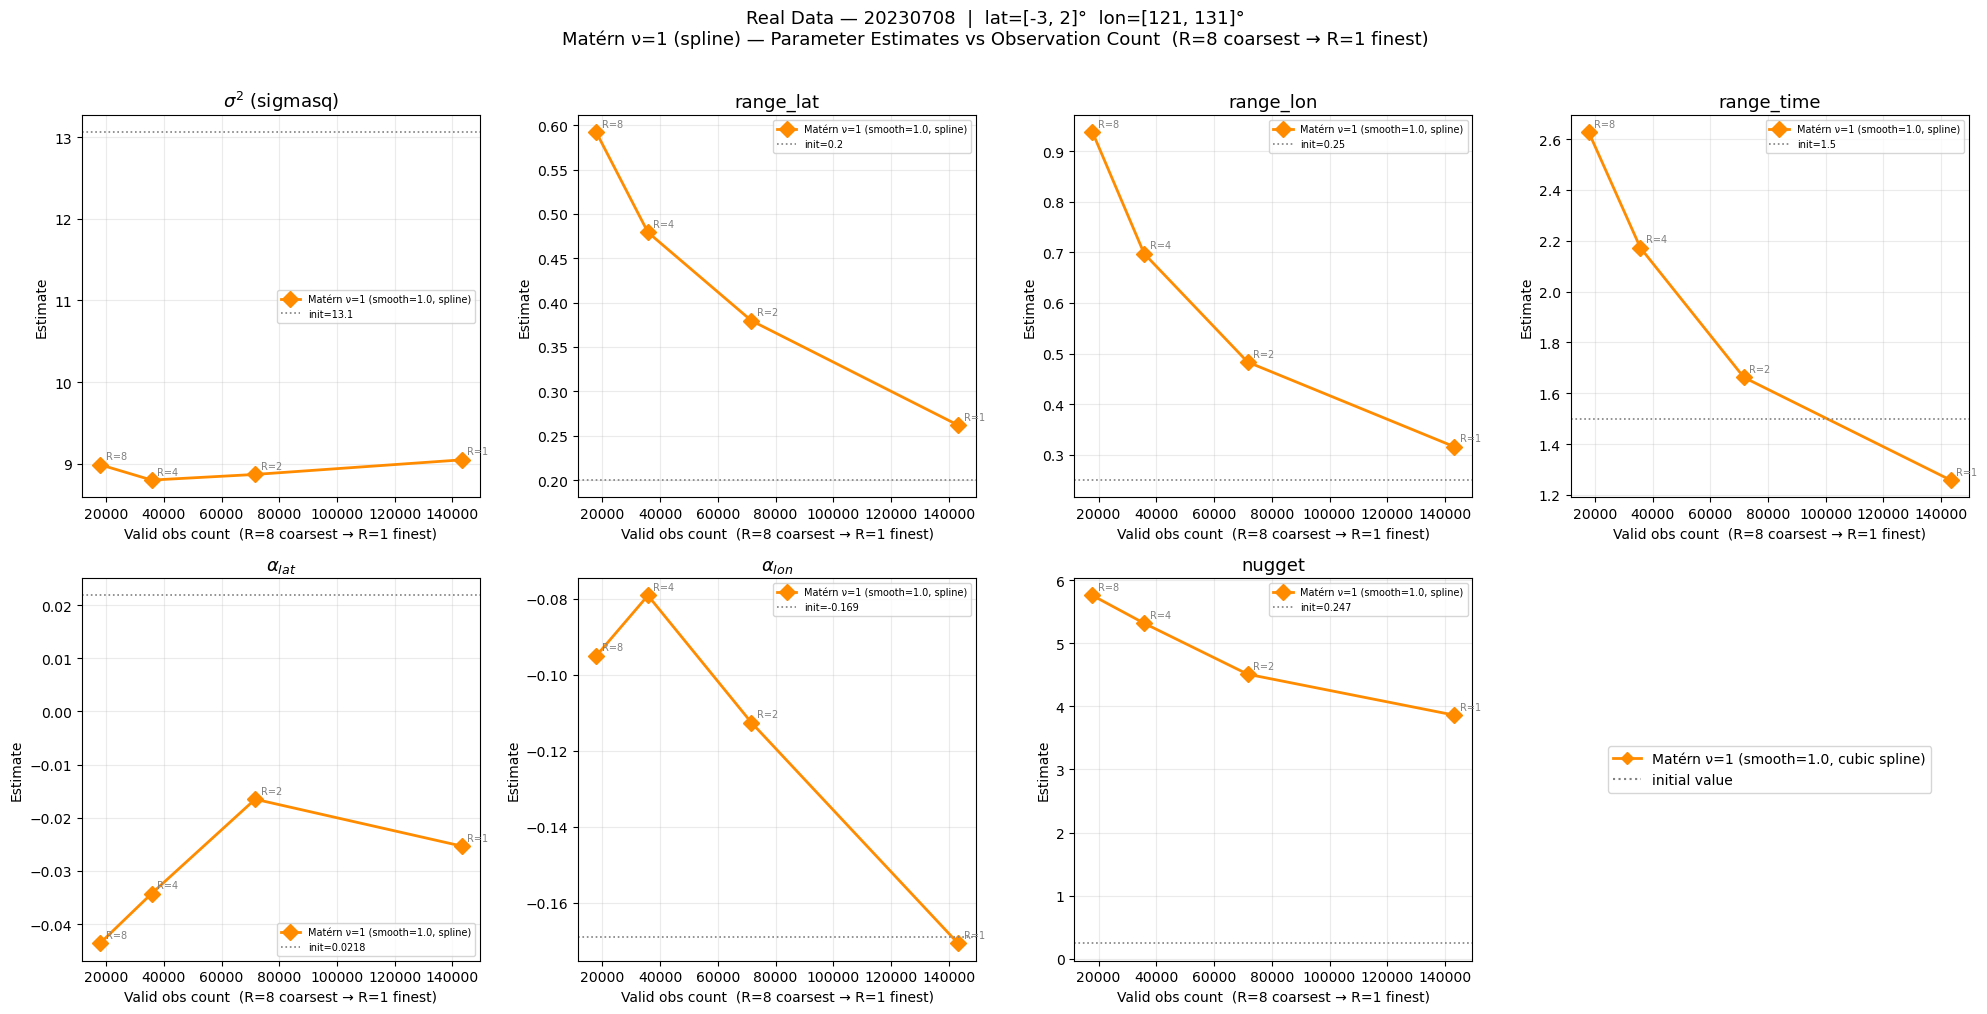

Saved: real_data_s10_param_trajectories_20230708.png

DAY 20230709:  2023_07_y23m07day09_hm00:53  …  2023_07_y23m07day09_hm07:48
  R= 8: n_grid= 2,266  valid_obs=  15,952
  R= 4: n_grid= 4,532  valid_obs=  31,737
  R= 2: n_grid= 9,063  valid_obs=  63,841
  R= 1: n_grid=18,126  valid_obs= 127,665

  Fitting: smooth=1.0  R=8  [n_obs=15,952]
[HybridVecchiaS10Lean] Matérn ν=1 spline built: 500 knots, r_max=15.0, f(0)=1.0000, f(1)=0.4443, device=cpu
Pre-computing HybridVecchia (smooth=1.0) [A=20, AB=33, ABC=41, B=local8+fresh4, C=local4+fresh3, lag1_offset=0.0630, stored=1]... [Mean Lat: -0.3982] [SetC=True] Done. (Heads=691, Tails A/AB/ABC=1903/1892/11466)
--- Starting Batched L-BFGS Optimization (GPU) ---
--- Step 1/10 / Loss: 1.635327 ---
  Param 0: Value=3.8903, Grad=-0.00728630786178636
  Param 1: Value=1.3274, Grad=0.017609262709931097
  Param 2: Value=1.0428, Grad=0.006732636056142749
  Param 3: Value=-2.8604, Grad=0.0029942805197938566
  Param 4: Value=0.0461, Grad=0.010920507881052

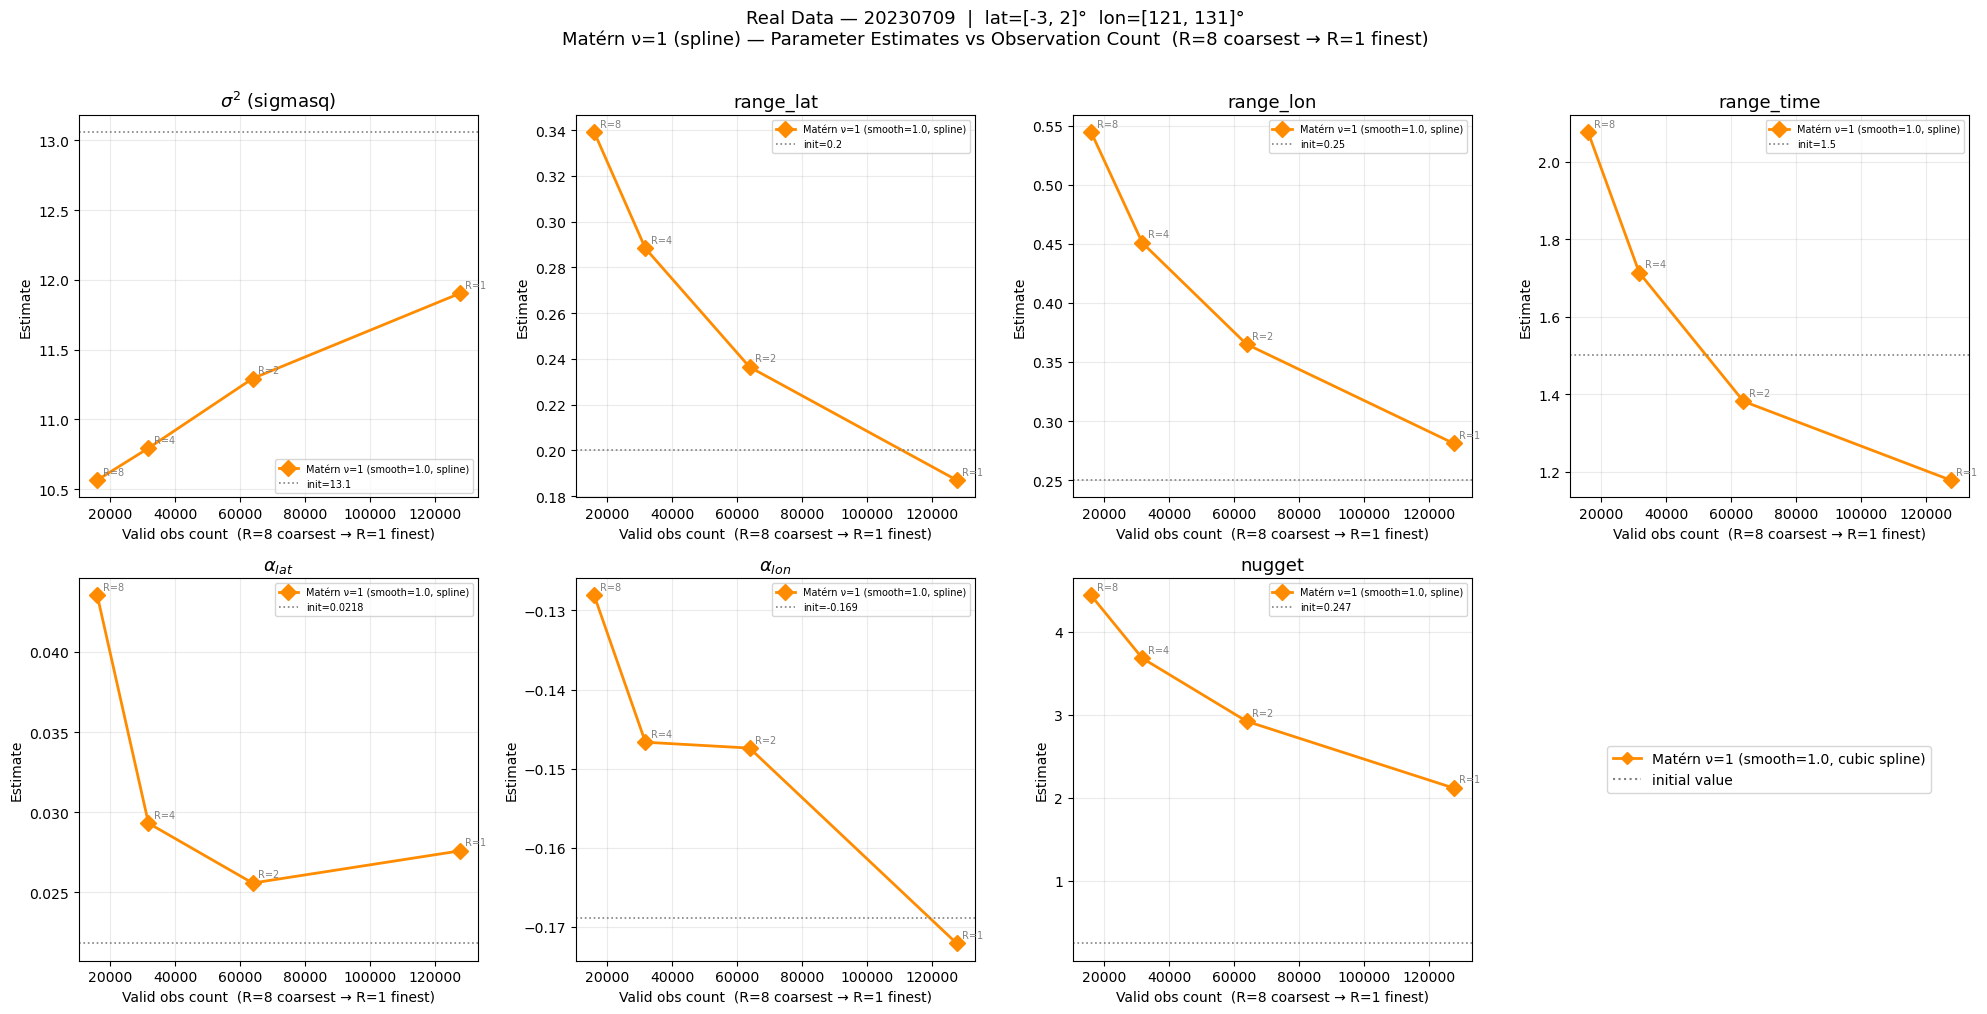

Saved: real_data_s10_param_trajectories_20230709.png

DAY 20230710:  2023_07_y23m07day10_hm00:53  …  2023_07_y23m07day10_hm07:48
  R= 8: n_grid= 2,266  valid_obs=  15,873
  R= 4: n_grid= 4,532  valid_obs=  31,770
  R= 2: n_grid= 9,063  valid_obs=  63,732
  R= 1: n_grid=18,126  valid_obs= 127,023

  Fitting: smooth=1.0  R=8  [n_obs=15,873]
[HybridVecchiaS10Lean] Matérn ν=1 spline built: 500 knots, r_max=15.0, f(0)=1.0000, f(1)=0.4443, device=cpu
Pre-computing HybridVecchia (smooth=1.0) [A=20, AB=33, ABC=41, B=local8+fresh4, C=local4+fresh3, lag1_offset=0.0630, stored=1]... [Mean Lat: -0.6330] [SetC=True] Done. (Heads=694, Tails A/AB/ABC=1904/1879/11396)
--- Starting Batched L-BFGS Optimization (GPU) ---
--- Step 1/10 / Loss: 1.569270 ---
  Param 0: Value=2.9081, Grad=0.02103781936298498
  Param 1: Value=0.0767, Grad=-0.001377837242582832
  Param 2: Value=1.8383, Grad=0.02038367660422777
  Param 3: Value=-2.5532, Grad=-0.006770313848721696
  Param 4: Value=0.0256, Grad=-0.061764039704108

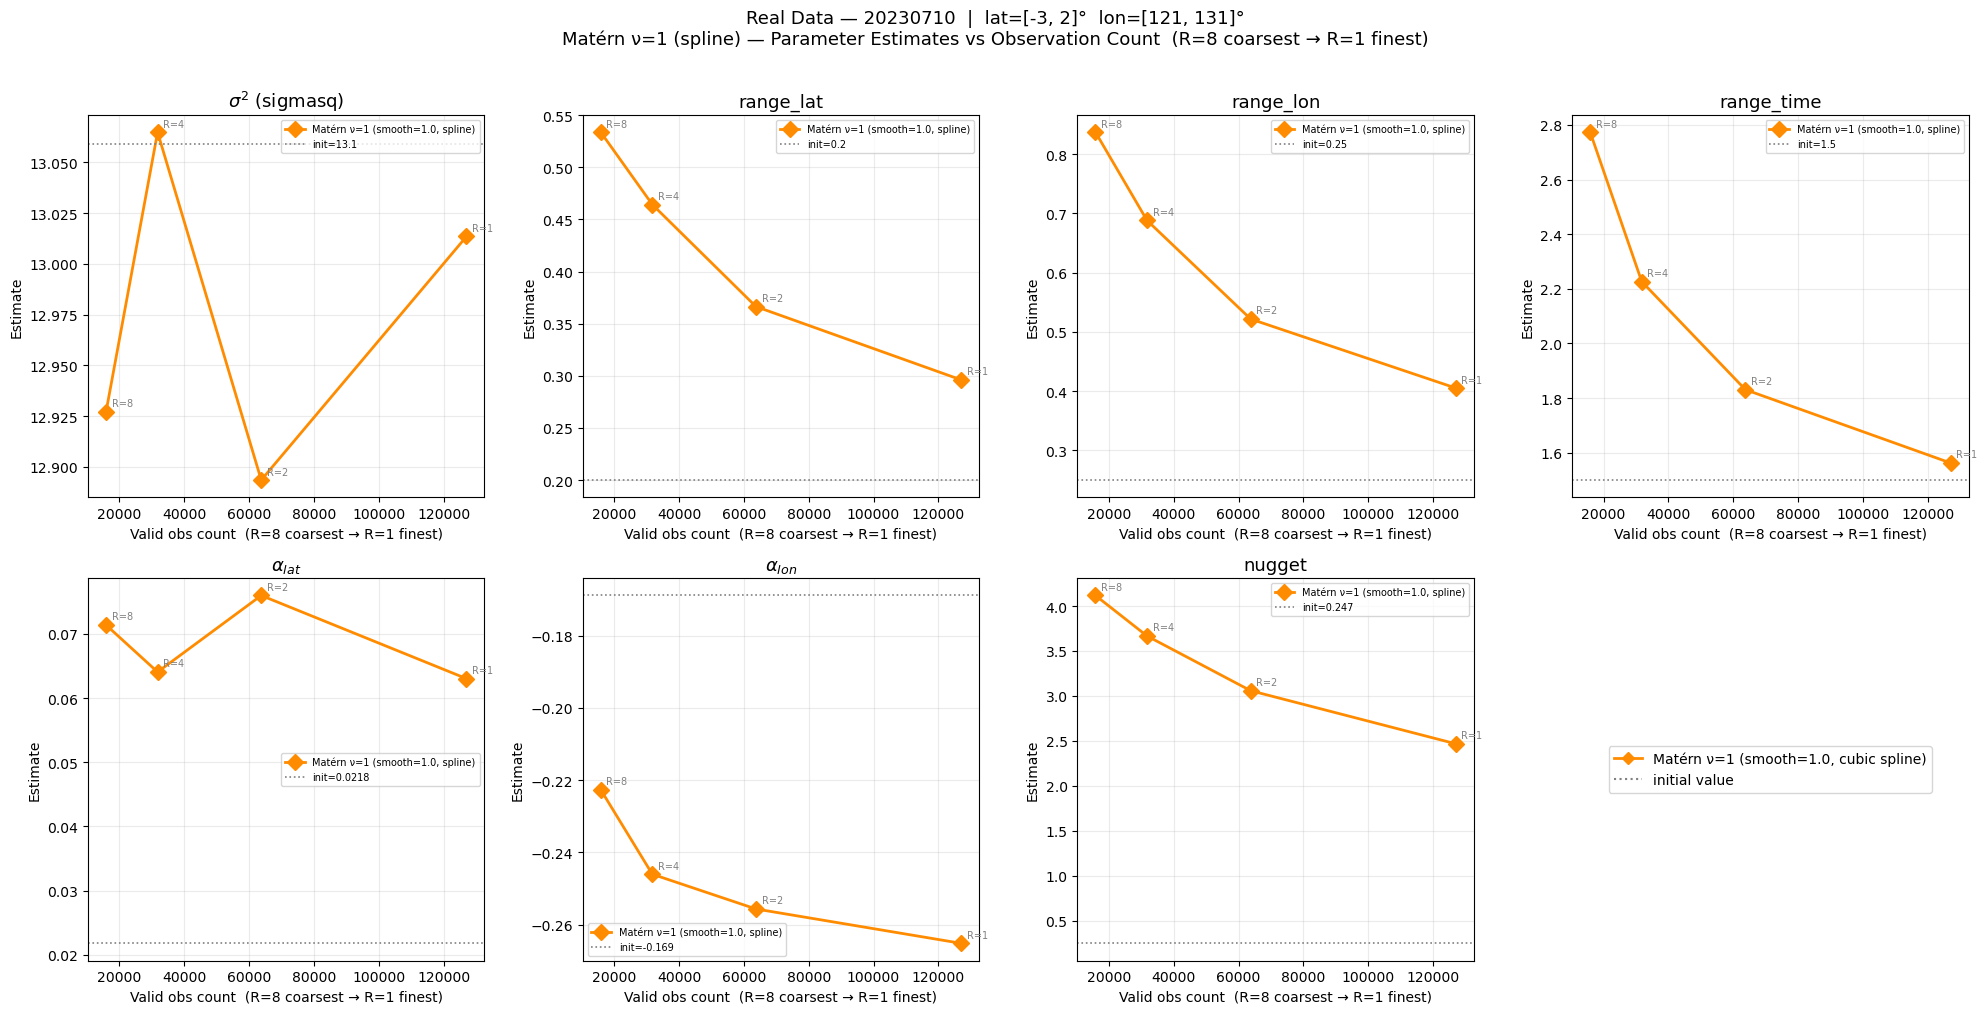

Saved: real_data_s10_param_trajectories_20230710.png

All done. 12 total fits across 3 day(s).


In [7]:
# ── fitting loop: per day × 4 resolutions  (smooth=1.0 fixed) ─────────
COLOR_S10 = 'darkorange'
MK_S10    = 'D'

all_results = []

for DAY_IDX in DAY_IDX_LIST:
    DATE_STR     = f"{YEAR}{MONTH:02d}{DAY_IDX+1:02d}"
    hour_indices = [DAY_IDX * 8, (DAY_IDX + 1) * 8]

    # ── load this day's data ──────────────────────────────────────────
    full_day_map, _ = loader.load_working_data(
        df_map, monthly_mean, hour_indices,
        ord_mm=ord_mm, dtype=DTYPE, keep_ori=True,
    )
    day_df_keys = sorted_df_keys[hour_indices[0]:hour_indices[1]]
    print(f'\n{"="*65}')
    print(f'DAY {DATE_STR}:  {day_df_keys[0]}  …  {day_df_keys[-1]}')

    # ── build per-resolution thin maps ────────────────────────────────
    setups = {}
    for R in RESOLUTION_MULTS:
        ns       = nns_setups[R]
        thin_map = {k: v[ns['thin_idx']] for k, v in full_day_map.items()}
        n_valid  = sum(int((~torch.isnan(v[:, 2])).sum()) for v in thin_map.values())
        setups[R] = {**ns, 'thin_map': thin_map, 'n_valid': n_valid}
        print(f'  R={R:2d}: n_grid={ns["n_grid"]:6,}  valid_obs={n_valid:8,}')

    # ── fit 4 resolutions, smooth=1.0 (cubic spline Matérn ν=1) ──────
    results = []
    INIT_LOG = phys_to_log(INIT_DICT)

    for R in RESOLUTION_MULTS:
        setup = setups[R]
        tag   = f'smooth=1.0  R={R}  [n_obs={setup["n_valid"]:,}]'
        print(f'\n  Fitting: {tag}')

        params = [
            torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True)
            for v in INIT_LOG
        ]

        model = HybridVecchiaS10Lean(
            input_map={k: v.to(DEVICE) for k, v in setup['thin_map'].items()},
            nns_map=setup['nns'],
            mm_cond_number=MM_COND_NUMBER,
            nheads=NHEADS,
            limit_A=LIMIT_A,
            limit_B_local=LIMIT_B_LOCAL,
            limit_C_local=LIMIT_C_LOCAL,
            daily_stride=DAILY_STRIDE,
            spatial_coords=setup['spatial_coords'],
            lag1_lon_offset=LAG1_LON_OFFSET,
            lag1_fresh_count=LAG1_FRESH,
            lag2_fresh_count=LAG2_FRESH,
        )
        model.precompute_conditioning_sets()

        optimizer = model.set_optimizer(
            params, lr=LBFGS_LR,
            max_iter=LBFGS_EVAL, max_eval=LBFGS_EVAL,
            history_size=LBFGS_HIST,
        )
        t0 = time.time()
        out, fit_iter = model.fit_vecc_lbfgs(
            params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5,
        )
        elapsed = time.time() - t0

        loss = float(out[-1])
        est  = backmap_params(out)
        print(f'    loss={loss:.4f}  elapsed={elapsed:.1f}s  steps={fit_iter+1}')

        results.append({
            'date_str':    DATE_STR,
            'day_idx':     DAY_IDX,
            'fit_smooth':  1.0,
            'R':           R,
            'n_obs_total': setup['n_valid'],
            'n_grid':      setup['n_grid'],
            'loss':        loss,
            'fit_steps':   fit_iter + 1,
            'elapsed_s':   round(elapsed, 1),
            **{f'est_{k}': est[k] for k in P_LABELS},
        })
        del model
        gc.collect()

    df_day = pd.DataFrame(results)
    all_results.append(df_day)

    # ── plot for this day ─────────────────────────────────────────────
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    sub = df_day.sort_values('n_obs_total')
    for i, (param, plabel) in enumerate(zip(P_LABELS, P_DISP)):
        ax   = axes[i]
        init = INIT_DICT[param]

        ax.plot(
            sub['n_obs_total'], sub[f'est_{param}'],
            color=COLOR_S10, marker=MK_S10, ms=8, lw=2,
            label='Matérn ν=1 (smooth=1.0, spline)',
        )
        for _, row in sub.iterrows():
            ax.annotate(
                f"R={int(row.R)}",
                (row['n_obs_total'], row[f'est_{param}']),
                textcoords='offset points', xytext=(4, 4),
                fontsize=7, color='grey',
            )

        ax.axhline(init, color='grey', ls=':', lw=1.2, label=f'init={init:.3g}')
        ax.set_title(plabel, fontsize=13)
        ax.set_xlabel('Valid obs count  (R=8 coarsest → R=1 finest)')
        ax.set_ylabel('Estimate')
        ax.legend(fontsize=7, loc='best')
        ax.grid(True, alpha=0.25)

    axes[-1].set_visible(False)
    legend_entries = [
        mlines.Line2D([], [], color=COLOR_S10, marker=MK_S10, lw=2,
                      label='Matérn ν=1 (smooth=1.0, cubic spline)'),
        mlines.Line2D([], [], color='grey', ls=':', lw=1.5, label='initial value'),
    ]
    axes[-1].legend(handles=legend_entries, loc='center', fontsize=10, frameon=True)
    axes[-1].set_visible(True)
    axes[-1].axis('off')

    fig.suptitle(
        f'Real Data — {DATE_STR}  |  lat={LAT_RANGE}°  lon={LON_RANGE}°\n'
        'Matérn ν=1 (spline) — Parameter Estimates vs Observation Count'
        '  (R=8 coarsest → R=1 finest)',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    fname = f'real_data_s10_param_trajectories_{DATE_STR}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

df = pd.concat(all_results, ignore_index=True)
print(f'\nAll done. {len(df)} total fits across {len(DAY_IDX_LIST)} day(s).')

In [8]:
# ── numerical summary across all days ────────────────────────────────
print('=' * 75)
print('REAL DATA RESOLUTION SENSITIVITY — Matérn ν=1 (smooth=1.0, cubic spline)')
print(f'days: {[f"{YEAR}{MONTH:02d}{d+1:02d}" for d in DAY_IDX_LIST]}')
print('=' * 75)

for date_str in df['date_str'].unique():
    sub_day = df[df.date_str == date_str].sort_values('n_obs_total')
    print(f'\n[{date_str}]  smooth=1.0')
    print(f"  {'n_obs':>8}  {'loss':>10}  {'sigmasq':>9}  {'range_lon':>10}  "
          f"{'range_time':>11}  {'nugget':>8}  {'advec_lon':>10}")
    for _, row in sub_day.iterrows():
        print(
            f"  {int(row.n_obs_total):>8}  {row.loss:>10.2f}  "
            f"{row.est_sigmasq:>9.4f}  {row.est_range_lon:>10.4f}  "
            f"{row.est_range_time:>11.4f}  {row.est_nugget:>8.4f}  "
            f"{row.est_advec_lon:>10.4f}"
        )

REAL DATA RESOLUTION SENSITIVITY — Matérn ν=1 (smooth=1.0, cubic spline)
days: ['20230708', '20230709', '20230710']

[20230708]  smooth=1.0
     n_obs        loss    sigmasq   range_lon   range_time    nugget   advec_lon
     17871        1.61     8.9882      0.9374       2.6269    5.7552     -0.0951
     35780        1.54     8.7992      0.6975       2.1721    5.3148     -0.0792
     71640        1.47     8.8684      0.4832       1.6623    4.5084     -0.1126
    143238        1.44     9.0471      0.3160       1.2585    3.8604     -0.1707

[20230709]  smooth=1.0
     n_obs        loss    sigmasq   range_lon   range_time    nugget   advec_lon
     15952        1.59    10.5651      0.5445       2.0764    4.4367     -0.1281
     31737        1.52    10.7943      0.4508       1.7134    3.6805     -0.1467
     63841        1.44    11.2933      0.3651       1.3814    2.9221     -0.1474
    127665        1.35    11.9032      0.2811       1.1780    2.1179     -0.1721

[20230710]  smooth=1.0
  

In [9]:
# ── parameter stability: range across resolutions per day ─────────────
print('PARAMETER RANGE ACROSS RESOLUTIONS (max - min, per day)')
print(f"  {'date':10s}  {'sigmasq':>9}  {'range_lat':>10}  {'range_lon':>10}  "
      f"{'range_time':>11}  {'nugget':>8}  {'advec_lon':>10}")
for date_str in df['date_str'].unique():
    sub = df[df.date_str == date_str]
    row_str = f'  {date_str:10s}'
    for k in P_LABELS:
        vals = sub[f'est_{k}'].values
        row_str += f'  {vals.max()-vals.min():>10.4f}'
    print(row_str)

PARAMETER RANGE ACROSS RESOLUTIONS (max - min, per day)
  date          sigmasq   range_lat   range_lon   range_time    nugget   advec_lon
  20230708        0.2479      0.3301      0.6215      1.3684      0.0271      0.0915      1.8948
  20230709        1.3381      0.1520      0.2635      0.8984      0.0180      0.0440      2.3188
  20230710        0.1714      0.2376      0.4319      1.2109      0.0130      0.0425      1.6505
